# Generalization Experiment: Bidirectional Downstream Classification Evaluation

This notebook evaluates the **bidirectional generalization experiment**.

It compares selected feature sets in both transfer directions:

1. **2-class domain supervision → 20-class downstream classification**
2. **20-class detail supervision → 2-class domain downstream classification**

Both directions are compared against the **unsupervised CAE** baseline and plotted next to each other in one figure.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULT_PATH = '../results_generalization/raw_generalization_results.csv'


## 1. Load results

In [2]:
df = pd.read_csv(RESULT_PATH)

# Backward compatibility:
# Older result files only contain feature_source = {unsupervised, supervised}
# and implicitly evaluate 2-class supervised features on the 20-class task.
if 'selection_task' not in df.columns:
    df['selection_task'] = df['feature_source'].map({
        'unsupervised': 'unsupervised',
        'supervised': 'domain_2class',
    }).fillna(df['feature_source'])

if 'evaluation_task' not in df.columns:
    df['evaluation_task'] = 'full_20class'

classification_cols = [
    'experiment',
    'feature_source',
    'selection_task',
    'evaluation_task',
    'seed',
    'k',
    'accuracy',
]

df_cls = df[classification_cols].copy()
df_cls


,experiment,feature_source,selection_task,evaluation_task,seed,k,accuracy
0,generalization_mnist_fashion,unsupervised,unsupervised,full_20class,0,50,0.817036
1,generalization_mnist_fashion,unsupervised,unsupervised,domain_2class,0,50,0.981964
2,generalization_mnist_fashion,supervised_domain_2class,domain_2class,full_20class,0,50,0.382714
3,generalization_mnist_fashion,supervised_domain_2class,domain_2class,domain_2class,0,50,0.982429
4,generalization_mnist_fashion,supervised_full_20class,full_20class,full_20class,0,50,0.827536
...,...,...,...,...,...,...,...
115,generalization_mnist_fashion,unsupervised,unsupervised,domain_2class,19,50,0.978929
116,generalization_mnist_fashion,supervised_domain_2class,domain_2class,full_20class,19,50,0.441179
117,generalization_mnist_fashion,supervised_domain_2class,domain_2class,domain_2class,19,50,0.977714
118,generalization_mnist_fashion,supervised_full_20class,full_20class,full_20class,19,50,0.829286


## 2. Mean ± std over seeds

In [3]:
summary = (
    df_cls
    .groupby(['selection_task', 'evaluation_task', 'feature_source', 'k'])[['accuracy']]
    .agg(['mean', 'std'])
    .reset_index()
)

summary


selection_task evaluation_task            feature_source   k  accuracy  \
                                                                    mean   
0  domain_2class   domain_2class  supervised_domain_2class  50  0.975802   
1  domain_2class    full_20class  supervised_domain_2class  50  0.404659   
2   full_20class   domain_2class   supervised_full_20class  50  0.988536   
3   full_20class    full_20class   supervised_full_20class  50  0.826718   
4   unsupervised   domain_2class              unsupervised  50  0.979095   
5   unsupervised    full_20class              unsupervised  50  0.813093   

             
        std  
0  0.009983  
1  0.037460  
2  0.001416  
3  0.002314  
4  0.003688  
5  0.005211

# 3. Significance

In [4]:
from scipy.stats import wilcoxon, ttest_rel
import pandas as pd

settings = [
    {
        "name": "2-class supervision → 20-class evaluation",
        "evaluation_task": "full_20class",
        "supervised_task": "domain_2class",
    },
    {
        "name": "20-class supervision → 2-class evaluation",
        "evaluation_task": "domain_2class",
        "supervised_task": "full_20class",
    },
]

for setting in settings:

    unsup = df_cls[
        (df_cls["selection_task"] == "unsupervised")
        & (df_cls["evaluation_task"] == setting["evaluation_task"])
    ][["seed", "accuracy"]].rename(
        columns={"accuracy": "unsupervised"}
    )

    sup = df_cls[
        (df_cls["selection_task"] == setting["supervised_task"])
        & (df_cls["evaluation_task"] == setting["evaluation_task"])
    ][["seed", "accuracy"]].rename(
        columns={"accuracy": "supervised"}
    )

    paired = (
        pd.merge(unsup, sup, on="seed")
        .sort_values("seed")
    )

    diff = paired["supervised"] - paired["unsupervised"]

    w_stat, w_p = wilcoxon(
        paired["supervised"],
        paired["unsupervised"],
    )

    t_stat, t_p = ttest_rel(
        paired["supervised"],
        paired["unsupervised"],
    )

    print("\n" + "=" * 70)
    print(setting["name"])
    print("=" * 70)

    print(
        f"Unsupervised mean: {paired['unsupervised'].mean():.4f}"
    )
    print(
        f"Supervised mean:   {paired['supervised'].mean():.4f}"
    )
    print(
        f"Mean difference:   {diff.mean():.4f}"
    )

    print(
        f"Wilcoxon:      statistic={w_stat:.4f}, p={w_p:.6f}"
    )
    print(
        f"Paired t-test: statistic={t_stat:.4f}, p={t_p:.6f}"
    )


2-class supervision → 20-class evaluation
Unsupervised mean: 0.8131
Supervised mean:   0.4047
Mean difference:   -0.4084
Wilcoxon:      statistic=0.0000, p=0.000002
Paired t-test: statistic=-45.2144, p=0.000000

20-class supervision → 2-class evaluation
Unsupervised mean: 0.9791
Supervised mean:   0.9885
Mean difference:   0.0094
Wilcoxon:      statistic=0.0000, p=0.000002
Paired t-test: statistic=11.4829, p=0.000000


## 4. Plot both transfer directions side by side


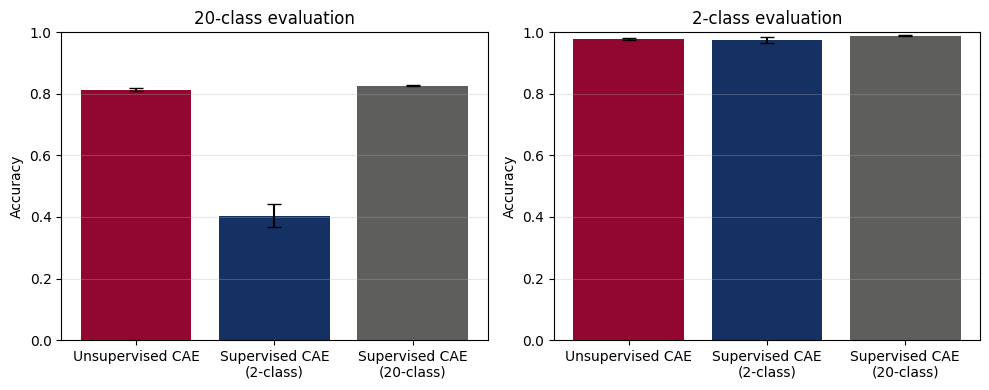

In [8]:
import numpy as np
import matplotlib.pyplot as plt

palette = {
    "unsupervised": "#910730",
    "supervised_domain_2class": "#153163",
    "supervised_full_20class": "#5E5E5D",
}

label_map = {
    "unsupervised": "Unsupervised CAE",
    "supervised_domain_2class": "Supervised CAE\n(2-class)",
    "supervised_full_20class": "Supervised CAE\n(20-class)",
}

plot_specs = [
    {
        "title": "20-class evaluation",
        "evaluation_task": "full_20class",
    },
    {
        "title": "2-class evaluation",
        "evaluation_task": "domain_2class",
    },
]

feature_sources = [
    "unsupervised",
    "supervised_domain_2class",
    "supervised_full_20class",
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

for ax, spec in zip(axes, plot_specs):
    means = []
    stds = []

    for feature_source in feature_sources:
        subset = df_cls[
            (df_cls["feature_source"] == feature_source)
            & (df_cls["evaluation_task"] == spec["evaluation_task"])
        ]

        means.append(subset["accuracy"].mean() if not subset.empty else np.nan)
        stds.append(subset["accuracy"].std() if len(subset) > 1 else 0.0)

    x = np.arange(len(feature_sources))

    ax.bar(
        x,
        means,
        yerr=stds,
        capsize=5,
        color=[palette[s] for s in feature_sources],
    )

    ax.set_title(spec["title"])
    ax.set_xticks(x)
    ax.set_xticklabels([label_map[s] for s in feature_sources])
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()